# Grammar Scoring Engine — Final Submission (E027)

Predict a continuous grammar score for 45–60 s spoken English recordings.

**Final model:** a calibrated blend of three channels.

1. **Text** (40%): an equal-weight ensemble of fine-tuned DeBERTa-v3 regressors that read
   default Whisper, disfluency-preserving ("verbatim") Whisper and literal wav2vec2 CTC
   transcripts.
2. **Audio** (30%): Ridge regressions on frozen WavLM-large and Whisper-encoder states, for
   what transcripts lose: pronunciation, rhythm, pauses.
3. **Audio language model** (30%): a Ridge on hidden states of Voxtral-Mini-3B, which listens
   to the clip together with a question about the speaker's grammar.

**Validation is the main lesson of this project.** Speakers repeat in the training set and are
mostly new in the test set, and short recordings are 24% of training but 69% of test. All
headline numbers are therefore reported on **unseen speakers, weighted to the test mix**.

| Metric on the training data | Value |
| --- | ---: |
| **RMSE, unseen speakers at the test mix (honest estimate)** | computed below — 0.544 |
| RMSE, unseen speakers, unweighted | computed below |
| RMSE, all 732 rows, cross-validated (optimistic: speakers repeat) | computed below |
| Public leaderboard | 0.3362 |

This notebook is the report: approach, preprocessing, architecture, evaluation and charts. It
recomputes every number from stored predictions and frozen features (extracted once on GPU with
the package code referenced below), refits the small Ridge models, and writes the 216-row
`submission.csv`. It runs on CPU in about a minute.

## 1. Approach in one paragraph

Grammar is a property of *what was said*, so the core is **audio → transcript → text
regressor**. Default Whisper output is too clean for grammar scoring (it drops fillers and
quietly fixes errors: "I liked *to* playground" → "I liked *the* playground"), so the text
models also read verbatim and CTC transcripts that keep the errors. Raters also hear fluency
and pronunciation, so two audio channels are added from frozen speech models. Because 732
clips are far too few to train speech models, the large models stay frozen and only small
Ridge regressors learn from their states. Blend weights and a final linear calibration are
fitted only on predictions for speakers the models never heard.

```text
                ┌─ Whisper large-v3 (default)          → canonical ─┐
                ├─ Whisper large-v3 + disfluent prompt → verbatim v1 ┼─ 6 DeBERTa-v3 groups ─ mean ─► text
audio (.wav) ───┤  Whisper large-v3 + per-window cue   → verbatim v2 │   (large/base × dual/v2/CTC)
                ├─ wav2vec2-large CTC, no LM           → literal CTC ┘
                ├─ WavLM-large layer 20 ───────────── Ridge ─┐
                ├─ Whisper encoder layers 22–32 ───── Ridge ─┴─ mean ──────────────────────────► audio
                └─ Voxtral-Mini-3B (audio + question), layers 12–14 ── Ridge ──────────────────► voxtral

        score = clip(−0.441 + 1.109 × (0.40 × text + 0.30 × audio + 0.30 × voxtral), 1, 5)
```

## 2. Setup

Paths resolve automatically for a local checkout (run from `notebooks/`) or a Kaggle notebook
with the competition data and the private artifact dataset
`lijoraju94/grammar-scoring-e015-final-artifacts` attached. All reusable logic is imported
from the `grammar_scoring` package in this repository.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    REPO = Path("/kaggle/working/grammar-scoring")
    if not REPO.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/lijoraju/grammar-scoring.git",
                str(REPO),
            ],
            check=True,
        )
    DATA_DIR = next(Path("/kaggle/input").glob("**/Dataset_Final/train.csv")).parent
    FINAL_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-e015-final-artifacts*")
    )
    CANON_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-canonical-artifacts*")
    )
    OUTPUT_DIR = Path("/kaggle/working")
else:
    REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
    DATA_DIR = REPO / "data/raw/Dataset_Final"
    FINAL_DIR = REPO / "artifacts/final_e015"
    CANON_DIR = REPO / "artifacts/transcripts"
    OUTPUT_DIR = REPO / "artifacts/final_e015"
sys.path.insert(0, str(REPO / "src"))
print("data:", DATA_DIR, "| artifacts:", FINAL_DIR)

data: /Volumes/Transcend/Kaggle Competition/grammar-scoring/data/raw/Dataset_Final | artifacts: /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from grammar_scoring.evaluation.metrics import regression_metrics
from grammar_scoring.experiments.e014_ensemble import ensemble_report, load_groups
from grammar_scoring.experiments.e014_finetune import load_transcripts
from grammar_scoring.experiments.e027_honest_blend import (
    AUDIO_ALPHA,
    AUDIO_FEATURES,
    CHANNELS,
    SHORT_SECONDS,
    VOXTRAL_ALPHA,
    VOXTRAL_FEATURE,
    apply_calibration,
    best_weights,
    fit_calibration,
    importance_weights,
    load_features,
    nested_honest_blend,
    ridge_channel,
    speaker_groups,
    unseen_speaker_mask,
    weighted_rmse,
)
from grammar_scoring.features.disfluency import text_features

# Validated categorical palette (fixed order) and recessive ink for axes and text.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
    }
)

## 3. Data and preprocessing

* **Rows:** 769 training and 216 test recordings (WAV, 45–60 s). Labels are MOS Likert grammar
  scores in half-point steps.
* **Zero-label block (excluded):** 37 training rows labelled 0, all from one contiguous file
  block (`audio_5037`–`audio_5073`) with heavy background noise and otherwise fluent speech.
  They behave like a different source (they contributed ~43% of squared error in early
  models) and no test file comes from that block, so the final population keeps the
  **732 rows with label > 0**. Filenames are only diagnostic; they are never features.
* **Folds:** five frozen folds created once and reused by every experiment, so all OOF
  numbers are comparable. Validation folds never influence training, checkpoint weights or
  test predictions of their own fold.
* **Audio preprocessing:** Whisper resamples to 16 kHz mono internally; no VAD, no denoising
  and no text normalization are applied, so disfluencies survive into the transcripts.

train rows: 769 | test rows: 216 | zero labels: 37


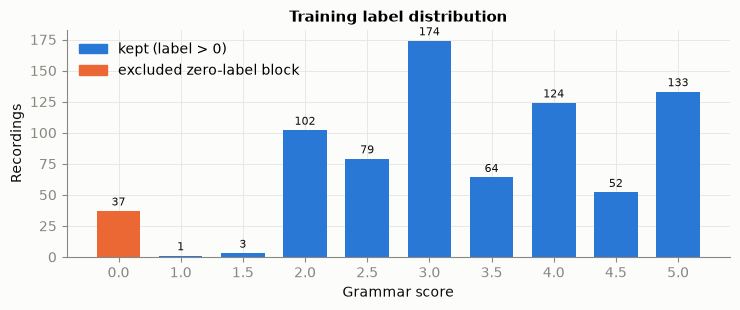

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
n_zero = int((train.label == 0).sum())
print(f"train rows: {len(train)} | test rows: {len(test)} | zero labels: {n_zero}")

counts = train.label.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colors = [ORANGE if label == 0 else BLUE for label in counts.index]
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.7)
ax.bar_label(bars, padding=2, color=INK, fontsize=8)
ax.set(title="Training label distribution", xlabel="Grammar score", ylabel="Recordings")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=BLUE),
        plt.Rectangle((0, 0), 1, 1, color=ORANGE),
    ],
    labels=["kept (label > 0)", "excluded zero-label block"],
    frameon=False,
)
plt.tight_layout()
plt.show()

## 4. ASR: why verbatim transcripts matter

Whisper transcripts come from **faster-whisper large-v3** (English, beam 5, no VAD); the CTC
transcript comes from **wav2vec2-large-960h-lv60-self** with greedy decoding:

| Transcript | Decoding | Purpose |
| --- | --- | --- |
| canonical | default settings, no prompt | clean, well-punctuated text |
| verbatim v1 | disfluent `initial_prompt`, conditioned on previous text | keep fillers, false starts and errors |
| verbatim v2 | disfluent style cue re-inserted in **every** 30 s window, no text conditioning, stricter compression-ratio fallback | same goal, without v1's rare repetition loops / prompt leakage |
| CTC | wav2vec2 frame-level characters, greedy, 20 s chunks with 4 s overlap; lower-case, no punctuation | fully literal: no language model to repair errors |

Code: `src/grammar_scoring/transcription/verbatim.py` (variants `v1`, `v2`) and
`src/grammar_scoring/transcription/ctc.py`. CTC adds literal *words* ("i like to playground",
"a lot kids") rather than fillers, which its read-speech training data lacks. It heard no speech in 17 of the 37
excluded zero-label clips, independent support for treating that block as noisy audio.

In [4]:
versions = {
    "canonical": CANON_DIR,
    "verbatim v1": FINAL_DIR / "transcripts_verbatim_v1",
    "verbatim v2": FINAL_DIR / "transcripts_verbatim_v2",
    "CTC": FINAL_DIR / "transcripts_ctc",
}
texts = {
    name: load_transcripts(path / "train.jsonl") for name, path in versions.items()
}
example = "audio_61.wav"
print(f"{example} — label {train.set_index('filename').label[example]}\n")
for name, mapping in texts.items():
    print(f"[{name}]\n{mapping[example][:330]}…\n")

audio_61.wav — label 2.0

[canonical]
Well, when I was a child, I remember I went to the kindergarten, and I liked the playground. I remember there are a lot of kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those it was so good because you need just enjoy enjoy play play play with the with the land play with the cars or play video g…

[verbatim v1]
Well, when I was a child, I remember I went to the kindergarten and I liked to playground. I remember there are a lot kids, a lot, well, the teacher, um, just enjoy your life. You didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, play, play with the- with the land, play with the cars, or, …

[verbatim v2]
Well, when I was a child, I remember I went to the kindergarten and I liked the playground. I remember there are a lot kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, p

,canonical,verbatim v1,verbatim v2,CTC
disf_filler_rate,0.34,4.06,3.76,0.24
disf_false_start_rate,0.00,1.86,1.49,0.00


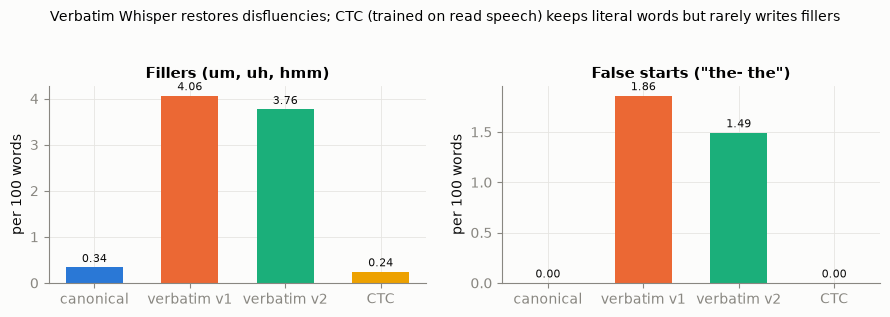

In [5]:
# Disfluency rates per 100 words from the package feature code (labels unused).
canonical = texts["canonical"]
rates = (
    pd.DataFrame(
        {
            name: pd.DataFrame(
                [text_features(canonical[k], mapping[k]) for k in canonical]
            ).mean()
            for name, mapping in texts.items()
        }
    ).loc[["disf_filler_rate", "disf_false_start_rate"]]
    * 100
)
display(rates.round(2))

panels = [
    ("disf_filler_rate", "Fillers (um, uh, hmm)"),
    ("disf_false_start_rate", 'False starts ("the- the")'),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (metric, title) in zip(axes, panels, strict=True):
    bars = ax.bar(
        rates.columns, rates.loc[metric], color=[BLUE, ORANGE, AQUA, YELLOW], width=0.6
    )
    ax.bar_label(bars, fmt="%.2f", padding=2, color=INK, fontsize=8)
    ax.set(title=title, ylabel="per 100 words")
fig.suptitle(
    "Verbatim Whisper restores disfluencies; CTC (trained on read speech) "
    "keeps literal words but rarely writes fillers",
    y=1.04,
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 5. Model architecture and training

Implemented in `src/grammar_scoring/experiments/e014_finetune.py`:

* **Backbone:** `microsoft/deberta-v3-large` (435M) or `deberta-v3-base` (184M), fully
  fine-tuned; encoder dropout disabled (it hurts regression targets).
* **Head:** attention-mask-aware mean pooling → linear layer; head bias initialised to the
  training-fold mean label.
* **Loss / optimiser:** MSE; AdamW (weight decay 0.01), linear warm-up (10%) and decay,
  5 epochs, effective batch 16, fp16 autocast, max 320 tokens. Large: lr 1e-5 with layer-wise
  LR decay 0.9; base: lr 2e-5. Head lr 1e-3.
* **Dual-transcript training:** every training clip contributes two examples (canonical and
  verbatim v1, same label); validation/test predictions average the two texts.
* **Model selection:** per fold, the epoch with the best validation RMSE (same rule as all
  earlier experiments); its test predictions are kept and averaged over the five folds.
* **Seeds:** 42, 7, 2024 (fixed and recorded per run).

In [6]:
GROUPS = {
    "large_dual": "DeBERTa-large · canonical + verbatim v1",
    "base_dual": "DeBERTa-base · canonical + verbatim v1",
    "large_v2": "DeBERTa-large · verbatim v2",
    "base_v2": "DeBERTa-base · verbatim v2",
    "large_ctc": "DeBERTa-large · CTC",
    "base_ctc": "DeBERTa-base · CTC",
}
run_dirs = {g: sorted((FINAL_DIR / "runs" / g).iterdir()) for g in GROUPS}
rows = []
for group, dirs in run_dirs.items():
    for d in dirs:
        r = json.loads((d / "result.json").read_text())
        rows.append(
            {
                "group": group,
                "run": r["run_name"],
                "seed": r["config"]["seed"],
                "OOF RMSE": r["oof_rmse"],
                "OOF Pearson": r["oof_pearson"],
                "GPU": r["device"],
                "minutes": r["minutes"],
            }
        )
runs_table = pd.DataFrame(rows)
display(runs_table.round(4))

,group,run,seed,OOF RMSE,OOF Pearson,GPU,minutes
0,large_dual,deberta-v3-large_dual_lr1e-05_s2024,2024,0.5818,0.8197,Tesla T4,41.3381
1,large_dual,deberta-v3-large_dual_lr1e-05_s42,42,0.5685,0.8284,Tesla T4,39.8586
2,large_dual,deberta-v3-large_dual_lr1e-05_s7,7,0.5882,0.8159,Tesla T4,39.2701
3,base_dual,deberta-v3-base_dual_lr2e-05_s2024,2024,0.5864,0.8158,Tesla T4,11.8509
4,base_dual,deberta-v3-base_dual_lr2e-05_s42,42,0.5787,0.8213,Tesla T4,12.3974
5,base_dual,deberta-v3-base_dual_lr2e-05_s7,7,0.5848,0.8172,Tesla T4,11.8354
6,large_v2,deberta-v3-large_lr1e-05_s42,42,0.5762,0.8241,Tesla T4,19.2211
7,large_v2,deberta-v3-large_lr1e-05_s7,7,0.5785,0.8227,Tesla T4,19.0433
8,base_v2,deberta-v3-base_lr2e-05_s42,42,0.5929,0.8127,Tesla T4,6.0521
9,base_v2,deberta-v3-base_lr2e-05_s7,7,0.5931,0.8119,Tesla T4,5.6341


## 6. Text ensemble (random-fold out-of-fold predictions)

Row *i* in fold *k* is predicted by the fold-*k* model trained on the other four folds; seeds
are averaged inside each group and the six groups with equal weight. These folds are random,
so a clip's speaker is often in the training folds too: Section 7 measures what that hides.

In [7]:
oof, test_pred = load_groups(run_dirs)
report = ensemble_report(oof, list(GROUPS))
summary = pd.DataFrame(
    [{"model": GROUPS[g], "runs": len(run_dirs[g]), **report[g]} for g in GROUPS]
    + [
        {
            "model": "TEXT ENSEMBLE: equal-weight mean of the 6 groups",
            "runs": sum(map(len, run_dirs.values())),
            **report["mean"],
        }
    ]
).rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
display(summary.round(4))
text_oof = oof[list(GROUPS)].mean(axis=1).to_numpy()
text_test = test_pred[list(GROUPS)].mean(axis=1).to_numpy()
y = oof["label"].to_numpy()
folds = oof["fold"].to_numpy()

,model,runs,RMSE,Pearson
0,DeBERTa-large · canonical + verbatim v1,3,0.5704,0.8269
1,DeBERTa-base · canonical + verbatim v1,3,0.5732,0.8249
2,DeBERTa-large · verbatim v2,2,0.5699,0.8279
3,DeBERTa-base · verbatim v2,2,0.5826,0.8188
4,DeBERTa-large · CTC,2,0.5894,0.8148
5,DeBERTa-base · CTC,2,0.6099,0.7999
6,TEXT ENSEMBLE: equal-weight mean of the 6 groups,14,0.5466,0.8426


## 7. Why random-fold validation was too optimistic

Two properties of the data, both found by checking the model's errors rather than its average:

* **Speakers repeat.** Clips are grouped into speakers by voice similarity (x-vectors from
  `microsoft/wavlm-base-plus-sv`, centred, cosine > 0.93, connected components;
  `experiments/e027_honest_blend.speaker_groups`). Most training clips have another clip by
  the same speaker with almost the same score, but few test clips match a training speaker.
  A model can therefore look good by recognizing voices.
* **The test mix differs.** Recordings shorter than 50 s are a minority of the training set
  and the majority of the test set.

The honest yardstick is therefore: predictions for clips whose **speaker was absent from the
training folds**, weighted so short and long clips have their **test-set shares**.

speakers found: 377 for 732 training clips
training clips with another clip by the same speaker: 69%
score spread within a speaker: 0.19 (overall 1.01)
test clips matching a training speaker: 13%
short clips (< 50 s): train 24%, test 69%
unseen-speaker validation rows: 255 (133 short, 122 long)


,speaker also in training folds,speaker unseen
text ensemble RMSE,0.521,0.591


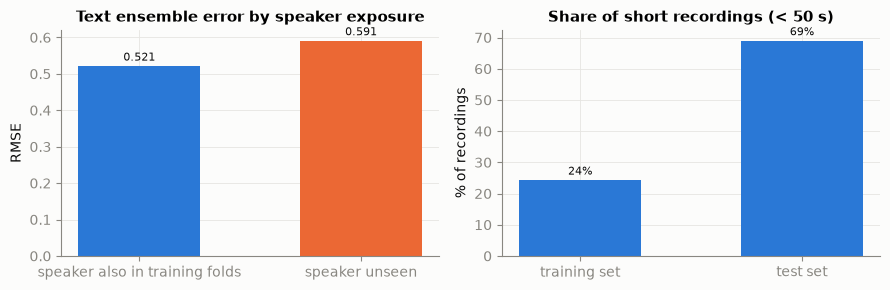

In [8]:
data = load_features(FINAL_DIR / "features_e027.npz")
train_index = {name: i for i, name in enumerate(data["train_filenames"])}
test_index = {name: i for i, name in enumerate(data["test_filenames"])}
rows = np.array([train_index[name] for name in oof["filename"]])
test_rows = np.array([test_index[name] for name in test_pred["filename"]])

# Speaker groups in sorted-filename order (deterministic group ids).
all_speakers = np.vstack([data["speaker_train"], data["speaker_test"]])
order = np.argsort(data["train_filenames"])
all_groups = np.empty(len(order), dtype=np.int64)
all_groups[order] = speaker_groups(data["speaker_train"][order], all_speakers)
groups = all_groups[rows]
short = data["duration_train"][rows] < SHORT_SECONDS
test_short = data["duration_test"][test_rows] < SHORT_SECONDS
unseen = unseen_speaker_mask(groups, folds)
weights = importance_weights(short, unseen, float(test_short.mean()))

sizes = pd.Series(groups).map(pd.Series(groups).value_counts()).to_numpy()
within = pd.Series(y[sizes > 1]).groupby(groups[sizes > 1]).std(ddof=0).mean()
centre = all_speakers.mean(axis=0)
unit = lambda e: (e - centre) / np.linalg.norm(e - centre, axis=1, keepdims=True)  # noqa: E731
match = (unit(data["speaker_test"]) @ unit(data["speaker_train"]).T).max(axis=1) > 0.93
print(f"speakers found: {len(np.unique(groups))} for {len(y)} training clips")
print(f"training clips with another clip by the same speaker: {np.mean(sizes > 1):.0%}")
print(f"score spread within a speaker: {within:.2f} (overall {y.std():.2f})")
print(f"test clips matching a training speaker: {match.mean():.0%}")
print(
    f"short clips (< {SHORT_SECONDS:.0f} s): train {short.mean():.0%}, "
    f"test {test_short.mean():.0%}"
)
print(
    f"unseen-speaker validation rows: {unseen.sum()} "
    f"({(unseen & short).sum()} short, {(unseen & ~short).sum()} long)"
)

rmse = lambda p, m: regression_metrics(y[m], p[m])["rmse"]  # noqa: E731
leak = pd.DataFrame(
    {
        "speaker also in training folds": [rmse(text_oof, ~unseen)],
        "speaker unseen": [rmse(text_oof, unseen)],
    },
    index=["text ensemble RMSE"],
)
display(leak.round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
bars = axes[0].bar(leak.columns, leak.iloc[0], color=[BLUE, ORANGE], width=0.55)
axes[0].bar_label(bars, fmt="%.3f", padding=2, color=INK, fontsize=8)
axes[0].set(title="Text ensemble error by speaker exposure", ylabel="RMSE")
bars = axes[1].bar(
    ["training set", "test set"],
    [short.mean() * 100, test_short.mean() * 100],
    color=BLUE,
    width=0.55,
)
axes[1].bar_label(bars, fmt="%.0f%%", padding=2, color=INK, fontsize=8)
axes[1].set(title="Share of short recordings (< 50 s)", ylabel="% of recordings")
plt.tight_layout()
plt.show()

## 8. Audio channels, validated on unseen speakers

Frozen features, extracted once on GPU (`features/audio_layers.py`,
`features/speaker_voxtral.py`), each averaged over time:

| Channel | Frozen model and states | Regressor |
| --- | --- | --- |
| audio | WavLM-large hidden layer 20; Whisper large-v3 encoder layers 22–32 (two models, averaged) | Ridge, α = 1000 |
| voxtral | Voxtral-Mini-3B LLM layers 12–14 at the audio-token positions, with the question "How accurate and complex is the speaker's grammar?" | Ridge, α = 3000 |

Every prediction below comes from **speaker-grouped folds**: the scaler and Ridge are fitted
on other speakers only. Earlier experiments used an RBF-SVR on the last WavLM layer with random
folds; it scored 0.50 on speakers it had heard and 0.73 on new speakers, i.e. it mostly
recognized voices. Upper layers with a strongly regularized linear model generalize better.

In [9]:
audio_oof, audio_test = ridge_channel(
    data, AUDIO_FEATURES, rows, test_rows, y, groups, AUDIO_ALPHA
)
voxtral_oof, voxtral_test = ridge_channel(
    data, (VOXTRAL_FEATURE,), rows, test_rows, y, groups, VOXTRAL_ALPHA
)
channels = np.column_stack([text_oof, audio_oof, voxtral_oof])
test_channels = np.column_stack([text_test, audio_test, voxtral_test])

table = pd.DataFrame(
    [
        {
            "channel": name,
            "honest RMSE (unseen speakers, test mix)": weighted_rmse(
                y[unseen], channels[unseen, i], weights[unseen]
            ),
            "short clips": rmse(channels[:, i], unseen & short),
            "long clips": rmse(channels[:, i], unseen & ~short),
        }
        for i, name in enumerate(CHANNELS)
    ]
)
display(table.round(4))
print(
    "speaker-grouped CV on all 732 rows: "
    f"audio {regression_metrics(y, audio_oof)['rmse']:.4f}, "
    f"voxtral {regression_metrics(y, voxtral_oof)['rmse']:.4f}"
)
print("correlation between channels on unseen-speaker rows:")
display(
    pd.DataFrame(
        np.corrcoef(channels[unseen].T), index=CHANNELS, columns=CHANNELS
    ).round(3)
)

,channel,"honest RMSE (unseen speakers, test mix)",short clips,long clips
0,text,0.5896,0.5870,0.5951
1,audio,0.6057,0.6067,0.6035
2,voxtral,0.5724,0.5607,0.5975


speaker-grouped CV on all 732 rows: audio 0.5656, voxtral 0.5528
correlation between channels on unseen-speaker rows:


,text,audio,voxtral
text,1.000,0.844,0.913
audio,0.844,1.000,0.905
voxtral,0.913,0.905,1.000


## 9. Blend, calibration and the training RMSE

* **Blend:** non-negative weights summing to one, chosen on a 0.05 grid to minimize the
  test-mix-weighted RMSE on unseen-speaker rows.
* **Calibration:** averaging channels shrinks predictions towards the mean, so a weighted line
  `label ≈ a + b × blend` is fitted on the same rows and predictions are clipped to [1, 5].
* **Nested:** for each fold, weights and line are fitted on the other folds' unseen-speaker
  rows only, so the reported number never uses a row's own label.

In [10]:
final_oof, fold_weights = nested_honest_blend(channels, y, folds, unseen, weights)
blend = best_weights(channels[unseen], y[unseen], weights[unseen])
line = fit_calibration(channels[unseen] @ blend, y[unseen], weights[unseen])
all_rows = apply_calibration(channels @ blend, line)

honest_rmse = weighted_rmse(y[unseen], final_oof[unseen], weights[unseen])
honest = regression_metrics(y[unseen], final_oof[unseen])
optimistic = regression_metrics(y, all_rows)
print("blend weights per fold (text, audio, voxtral):", fold_weights)
print(
    "final weights:",
    dict(zip(CHANNELS, blend.round(2).tolist(), strict=True)),
    f"| calibration: {line[0]:.4f} + {line[1]:.4f} × blend",
)
print(
    f"TRAINING DATA RMSE, unseen speakers at the test mix (honest): {honest_rmse:.4f}"
)
print(
    f"TRAINING DATA RMSE, unseen speakers, unweighted (n={unseen.sum()}): "
    f"{honest['rmse']:.4f} | Pearson {honest['pearson_correlation']:.4f}"
)
print(
    f"TRAINING DATA RMSE, all {len(y)} rows cross-validated (optimistic): "
    f"{optimistic['rmse']:.4f} | Pearson {optimistic['pearson_correlation']:.4f}"
)
by_length = pd.DataFrame(
    [
        {
            "clips": name,
            "n": int(m.sum()),
            "text only": rmse(text_oof, m),
            "final": rmse(final_oof, m),
            "mean error (final − label)": float((final_oof[m] - y[m]).mean()),
        }
        for name, m in [("short (< 50 s)", unseen & short), ("long", unseen & ~short)]
    ]
)
display(by_length.round(3))

blend weights per fold (text, audio, voxtral): [[0.35, 0.3, 0.35], [0.4, 0.4, 0.2], [0.4, 0.25, 0.35], [0.35, 0.2, 0.45], [0.4, 0.25, 0.35]]
final weights: {'text': 0.4, 'audio': 0.3, 'voxtral': 0.3} | calibration: -0.4414 + 1.1094 × blend
TRAINING DATA RMSE, unseen speakers at the test mix (honest): 0.5442
TRAINING DATA RMSE, unseen speakers, unweighted (n=255): 0.5452 | Pearson 0.8361
TRAINING DATA RMSE, all 732 rows cross-validated (optimistic): 0.5078 | Pearson 0.8680


,clips,n,text only,final,mean error (final − label)
0,short (< 50 s),133,0.587,0.542,0.017
1,long,122,0.595,0.548,-0.048


**Which number is "the" training RMSE?** The task asks for the RMSE on the training data. The
honest figure is the first line: every clip is scored by models that never heard its speaker,
with short and long clips weighted as in the test set. The last line uses all 732 rows but is
optimistic, because the fine-tuned text models saw other clips by the same speakers. An
in-sample RMSE (models scoring their own training clips) would be close to zero for fine-tuned
transformers and says nothing about new speakers, so it is not reported.

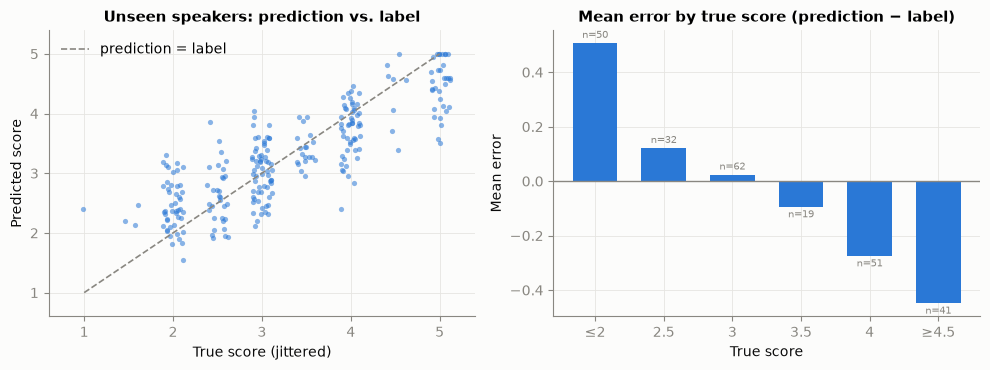

In [11]:
rng = np.random.default_rng(42)
yy, pp = y[unseen], final_oof[unseen]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
ax = axes[0]
ax.scatter(
    yy + rng.uniform(-0.12, 0.12, len(yy)),
    pp,
    s=14,
    alpha=0.55,
    color=BLUE,
    linewidths=0,
)
ax.plot(
    [1, 5],
    [1, 5],
    color=MUTED,
    linewidth=1.2,
    linestyle="--",
    label="prediction = label",
)
ax.legend(frameon=False, loc="upper left")
ax.set(
    title="Unseen speakers: prediction vs. label",
    xlabel="True score (jittered)",
    ylabel="Predicted score",
    xlim=(0.6, 5.4),
    ylim=(0.6, 5.4),
)
bands = pd.cut(
    yy,
    [0, 2.25, 2.75, 3.25, 3.75, 4.25, 5.0],
    labels=["≤2", "2.5", "3", "3.5", "4", "≥4.5"],
)
by_band = (
    pd.DataFrame({"band": bands, "residual": pp - yy})
    .groupby("band", observed=True)["residual"]
    .agg(["mean", "size"])
)
ax = axes[1]
bars = ax.bar(by_band.index.astype(str), by_band["mean"], color=BLUE, width=0.65)
ax.bar_label(
    bars, labels=[f"n={n}" for n in by_band["size"]], padding=2, fontsize=7, color=MUTED
)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set(
    title="Mean error by true score (prediction − label)",
    xlabel="True score",
    ylabel="Mean error",
)
plt.tight_layout()
plt.show()

The model still pulls extreme scores towards the middle: the weakest speakers are scored too
high and the strongest too low, even after calibration. With only four training clips below 2,
the bottom of the scale cannot be learned well.

## 10. How we got here (experiment log)

Public leaderboard scores (lower is better) for each submitted model, with the validation
figure available at the time. Up to E024, validation used random folds; its numbers kept
improving while the leaderboard reacted less and less, which is what led to the speaker and
test-mix analysis. From E026 on, the honest figure and the leaderboard move together.

,submission,random-fold RMSE,honest RMSE,public LB
0,"E008 DeBERTa-base, canonical transcript",0.6198,NaN,0.3925
1,E014 multi-seed base and large,0.5732,NaN,0.3894
2,"E015 + verbatim transcripts (dual, v2)",0.5545,NaN,0.3778
3,E020 + wav2vec2 CTC transcripts,0.5466,0.5900,0.3712
4,"E022 + WavLM audio (RBF-SVR, random folds)",0.5073,0.5880,0.3605
5,E024 + calibration,0.4942,0.5790,0.3501
6,"E026 honest audio (Ridge, upper layers)",NaN,0.5490,0.3448
7,E027 + Voxtral (final),NaN,0.5442,0.3362


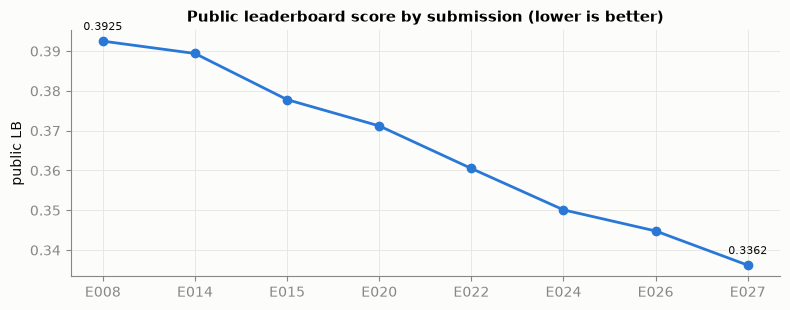

In [12]:
log = pd.DataFrame(
    [
        ("E008 DeBERTa-base, canonical transcript", 0.6198, np.nan, 0.3925),
        ("E014 multi-seed base and large", 0.5732, np.nan, 0.3894),
        ("E015 + verbatim transcripts (dual, v2)", 0.5545, np.nan, 0.3778),
        ("E020 + wav2vec2 CTC transcripts", 0.5466, 0.590, 0.3712),
        ("E022 + WavLM audio (RBF-SVR, random folds)", 0.5073, 0.588, 0.3605),
        ("E024 + calibration", 0.4942, 0.579, 0.3501),
        ("E026 honest audio (Ridge, upper layers)", np.nan, 0.549, 0.3448),
        ("E027 + Voxtral (final)", np.nan, honest_rmse, 0.3362),
    ],
    columns=["submission", "random-fold RMSE", "honest RMSE", "public LB"],
)
display(log.round(4))

fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.arange(len(log))
ax.plot(x, log["public LB"], color=BLUE, linewidth=2, marker="o", markersize=6)
ax.set_xticks(x, [name.split(" ")[0] for name in log["submission"]])
for i in (0, len(log) - 1):
    ax.annotate(
        f"{log['public LB'][i]:.4f}",
        (i, log["public LB"][i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
        color=INK,
    )
ax.set(
    title="Public leaderboard score by submission (lower is better)", ylabel="public LB"
)
plt.tight_layout()
plt.show()

**Tried and rejected:**

| Experiment | Result | Why rejected |
| --- | --- | --- |
| Handcrafted acoustic features + stacking (E006a, E012a, E013) | ≤0.005 gain | did not transfer to the leaderboard |
| CORAL ordinal head (E007) | no gain | |
| Qwen2.5-7B QLoRA regressor (E016) | RMSE 0.710 | weaker than DeBERTa |
| GEC edit rate + zero-shot LLM rubric judge features (E017) | ≤0.003 | no signal beyond the text ensemble |
| Disfluency / fluency / length features (E019) | 0.004 | only 3 of 5 folds improved |
| RoBERTa-large as a 7th text group (E021) | 0.5443 vs 0.5466 | only 3 of 5 folds improved |
| WavLM-large + Whisper all-layer means, RBF-SVR, random folds (E023) | random-fold 0.481, LB 0.3649 | learned voices; worse publicly |
| Per-duration blend on random-fold predictions (E025) | LB 0.3499 | tie with E024; validation was still speaker-leaky |
| Test-time audio normalization | worse under grouped folds | batch differences partly reflect real ability |
| Tree / Ridge stackers; rounding to the 0.5 grid | worse | too little data; rounding hurt every fold |
| Using a matched training speaker's score for test clips | −0.09 RMSE on matched clips | speaker recognition, not grammar scoring; left out on purpose |

## 11. Submission

The three channels' test predictions (text: fold-averaged models; audio and Voxtral: Ridge
refitted on all 732 rows) are blended with the weights above, calibrated with the line fitted
on unseen-speaker rows, and clipped to [1, 5]. The file is checked against the submission
scored on the public leaderboard (0.3362).

wrote /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015/submission.csv (216 rows)
matches the scored E027 submission: True


,count,mean,std,min,25%,50%,75%,max
label,216.0,3.241,0.869,1.542,2.566,3.111,3.738,5.0


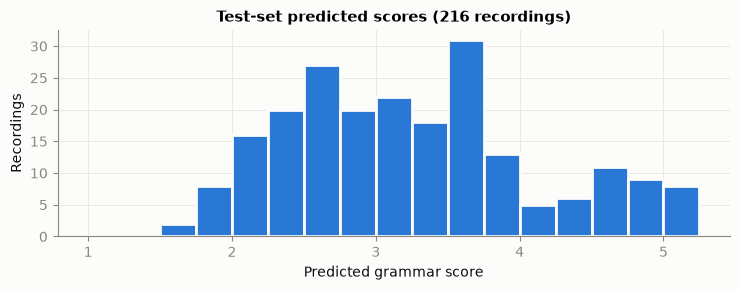

In [13]:
submission = pd.DataFrame(
    {
        "filename": test_pred["filename"],
        "label": apply_calibration(test_channels @ blend, line),
    }
)
assert submission["filename"].tolist() == test["filename"].tolist()
assert len(submission) == 216 and submission["filename"].is_unique
assert np.isfinite(submission["label"]).all()
path = OUTPUT_DIR / "submission.csv"
submission.to_csv(path, index=False)
print(f"wrote {path} ({len(submission)} rows)")
scored = FINAL_DIR / "e027" / "submission.csv"
if scored.exists():
    print(
        "matches the scored E027 submission:",
        np.allclose(
            pd.read_csv(scored)["label"], submission["label"], rtol=0, atol=1e-6
        ),
    )
display(submission.describe().round(3).T)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.hist(
    submission["label"],
    bins=np.arange(1.0, 5.26, 0.25),
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=2,
)
ax.set(
    title="Test-set predicted scores (216 recordings)",
    xlabel="Predicted grammar score",
    ylabel="Recordings",
)
plt.tight_layout()
plt.show()

## 12. Limitations and next steps

* **Small honest validation set.** Only 255 unseen-speaker rows support the blend and
  calibration; the honest RMSE moves by about ±0.01 with a different fold assignment.
* **Text models were trained on random folds.** They saw other clips by the same speakers, so
  their out-of-fold predictions are honest only on the unseen-speaker rows. Retraining them on
  speaker-grouped folds would give honest predictions for every row.
* **Speaker grouping is approximate.** It relies on a voice-similarity threshold; a few
  speakers may be split or merged.
* **ASR dependence.** Scores inherit recognition errors; verbatim decoding is prompt-driven.
* **Shrinkage and coarse labels.** Extreme scores are pulled towards the middle, and labels
  are human opinions on a 0.5 grid.
* **Zero-label block.** The 37 clips labelled 0 are excluded as a noisy batch (a CTC model
  hears no speech in about half of them); no test clip looks like them.

## 13. Reproducing

```sh
# transcripts and text models (GPU; one run per seed)
python scripts/transcribe_verbatim.py --data-dir <Dataset_Final> --output-dir <out> --variant v1
python scripts/transcribe_ctc.py --data-dir <Dataset_Final> --output-dir <ctc_out>
python scripts/run_e014_finetune.py --data-dir <Dataset_Final> --transcript-dir <canonical> \
    --alt-transcript-dir <verbatim_v1> --model-name microsoft/deberta-v3-large \
    --learning-rate 1e-5 --layer-decay 0.9 --gradient-checkpointing --seeds 42 7 2024 \
    --output-dir <runs>
# frozen audio features (GPU, once): WavLM / Whisper encoder / speaker x-vectors / Voxtral
python scripts/extract_audio_layers.py --data-dir <Dataset_Final> --output-dir <layers>
python -m grammar_scoring.features.speaker_voxtral --data-dir <Dataset_Final> \
    --output-dir <e026> --what speaker voxtral
# honest evaluation, blend, calibration and submission (CPU)
python scripts/run_e027_honest_blend.py --runs-dir <runs> --groups large_dual base_dual \
    large_v2 base_v2 large_ctc base_ctc --features <features.npz> --output-dir <out>
```